# Unsupervised NN

### Model Character
input:
- distribution of d_k (sum = 1)
- |H_k|

output:
- list of b_k
- list of f_dt_k
- list of beta_k

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch


if torch.backends.mps.is_available():
    device = 'mps'
    print("Success: Using Apple Silicon GPU acceleration.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("Success: Using Cuda GPU acceleration.")
else:
    device = 'cpu'
    print("Using CPU.")

Success: Using Apple Silicon GPU acceleration.


## Training

In [3]:
from TrainingUtil import set_seed

set_seed()

In [4]:
from DataUtil import generate_data_loader
import Constants

K = 4
B_total = Constants.total_bandwidth
C_DT_total = Constants.total_compute_speed
beta_max = 3

train_loader, test_loader = generate_data_loader(
    int(1e5), 
    K, 16e3, 
    comp_speed_range=[Constants.sensor_compression_speed/2, Constants.sensor_compression_speed*2], 
    tr_power_range=[Constants.transmit_power/2, Constants.transmit_power*2],
    beta_max=3.5
    )

In [5]:
from TrainingUtil import unsupervised_loss, train
from torch.optim import Adam, lr_scheduler
from EarlyStopping import EarlyStopping
from NNSolver import Net

model = Net(K, B_total, C_DT_total, beta_max)

optimizer = Adam(model.parameters(), lr=0.01)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=1e-2, patience=3)
early_stopper = EarlyStopping(patience=5, min_delta=0.1)
loss_fn = unsupervised_loss

train(model, train_loader, test_loader, optimizer, scheduler, early_stopper, loss_fn, device, n_epoch=100)

start training
epoch: 01, avg loss: 1792.3991490996468
epoch: 02, avg loss: 1792.2209743345215
epoch: 03, avg loss: 1792.5027071499367
epoch: 04, avg loss: 1792.3694787259294
epoch: 05, avg loss: 1792.3678738526953
epoch: 06, avg loss: 1792.3678738526953
epoch: 07, avg loss: 1792.3678738526953
best epoch: 02, best avg loss: 1792.220974


In [6]:
# state_dict = torch.load('model/checkpoint.pth', map_location=device, weights_only=True)
# model.to(device)
# model.load_state_dict(state_dict)

## Validation

In [8]:
import TrainingUtil as tu
import DataUtil as du
import AnalyzeUtil as au
import ProcessTime as process

uniform = torch.tensor([1, 1, 1, 1])
benchmark = torch.tensor([0.25, 0.75, 1.25, 1.75])

H = au.to_normal(-40)

H_k = torch.tensor([H, H, H, H])
test_d = benchmark * 1e3
test_beta = torch.tensor([1.5, 1.5, 1.5, 1.5])
test_comp_speed = uniform * Constants.sensor_compression_speed
test_tr_power = uniform * Constants.transmit_power
# test_comp_speed = torch.tensor([1, 1, 1, 1]) * 200e3
X_test = torch.cat((test_d, H_k, test_beta, test_comp_speed, test_tr_power)).reshape(1, -1).to(device)

NN

|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 2.50e+02 |  -40.00 | 1.000e+03 | 6.602e+05 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         0.20 |       0.42 |       3.79 |
|            1 | 7.50e+02 |  -40.00 | 1.002e+03 | 2.939e+06 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         0.59 |       1.26 |       2.55 |
|            2 | 1.25e+03 |  -40.00 | 1.946e+03 | 8.635e+06 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         0.98 |       1.97 |       1.45 |
|            3 | 1.75e+03 |  -40.00 | 9.605e+04 | 3.777e+07 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         1.38 |       2.56 |       0.46 |

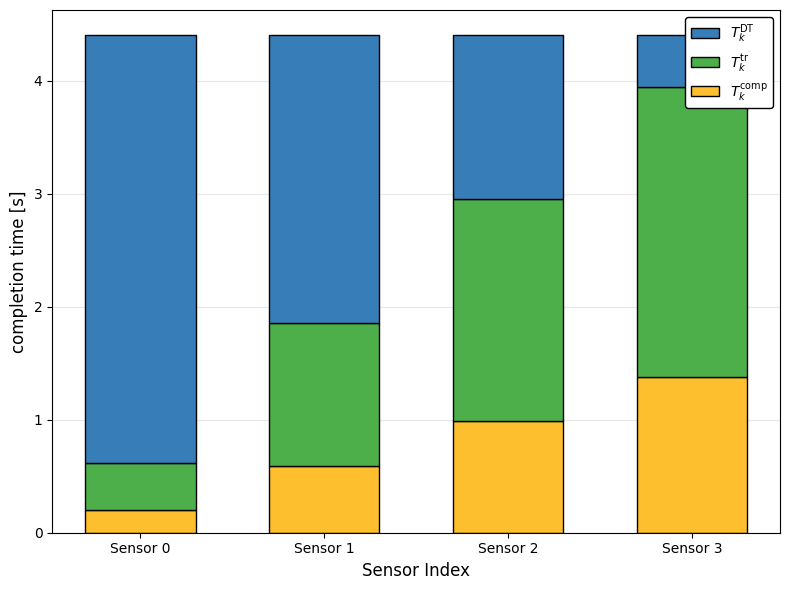

In [12]:
b, f = model(X_test)

b = b.to('cpu')
f = f.to('cpu')
au.plot_result(X_test.to('cpu'), b, f)
au.print_avg(X_test.to('cpu'), b, f)


CVX

|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 2.50e+02 |  -40.00 | 1.275e+03 | 6.597e+05 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         0.20 |       0.41 |       3.79 |
|            1 | 7.50e+02 |  -40.00 | 5.565e+03 | 2.801e+06 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         0.59 |       1.13 |       2.68 |
|            2 | 1.25e+03 |  -40.00 | 1.596e+04 | 7.983e+06 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         0.98 |       1.85 |       1.57 |
|            3 | 1.75e+03 |  -40.00 | 7.720e+04 | 3.856e+07 |   1.50 |     2.00e+05 |   3.16e-02 |          4.40 |         1.38 |       2.56 |       0.45 |

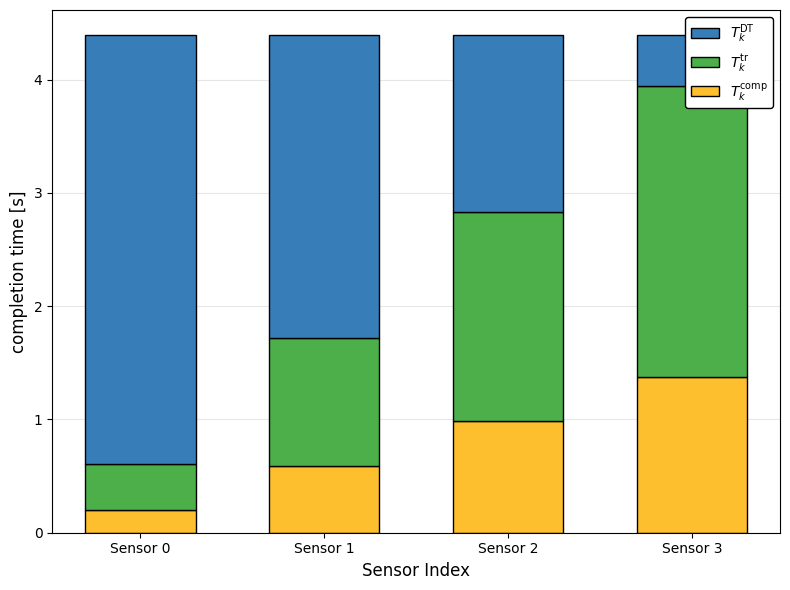

In [14]:
from CVXSolver import CVXSolver

cvx_solver = CVXSolver(
    K=K,
    B_total=Constants.total_bandwidth,
    C_DT_total=Constants.total_compute_speed,
    beta_max=Constants.beta_max,
)

b_cvx, f_cvx = cvx_solver.predict(X_test, verbose=False)

b_cvx = torch.tensor(b_cvx)
f_cvx = torch.tensor(f_cvx)

au.plot_result(X_test.to('cpu'), b_cvx, f_cvx)
au.print_avg(X_test.to('cpu'), b_cvx, f_cvx)

## Algorithm

In [29]:
from Algorithm import Algorithm

uniform = np.ones((1,4))
benchmark = np.array([0.25, 0.75, 1.25, 1.75])

rep = 100

D = (uniform * 4e3 ).reshape(1, -1)
D = np.repeat(D, rep, axis=0)

H = du.generate_channel_gains(rep, 4).numpy()

comp_speed = (uniform * Constants.sensor_compression_speed).reshape(1, -1).repeat(rep, axis=0)

tr_power = (benchmark * Constants.transmit_power).reshape(1, -1).repeat(rep, axis=0)

algo = Algorithm(D, H, comp_speed, tr_power)

NN

|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 4.00e+03 |  -40.77 | 4.975e+04 | 3.950e+07 |   1.63 |     2.00e+05 |   7.90e-03 |         53.34 |         6.20 |      41.20 |       5.94 |
|            1 | 4.00e+03 |  -40.65 | 2.147e+04 | 6.000e+06 |   1.39 |     2.00e+05 |   2.37e-02 |         53.34 |         2.53 |      17.17 |      33.64 |
|            2 | 4.00e+03 |  -40.80 | 1.535e+04 | 2.356e+06 |   1.30 |     2.00e+05 |   3.95e-02 |         53.34 |         1.37 |       9.52 |      42.45 |
|            3 | 4.00e+03 |  -40.79 | 1.343e+04 | 2.145e+06 |   1.24 |     2.00e+05 |   5.53e-02 |         53.34 |         1.06 |       7.91 |      44.37 |

0.021683083999960218

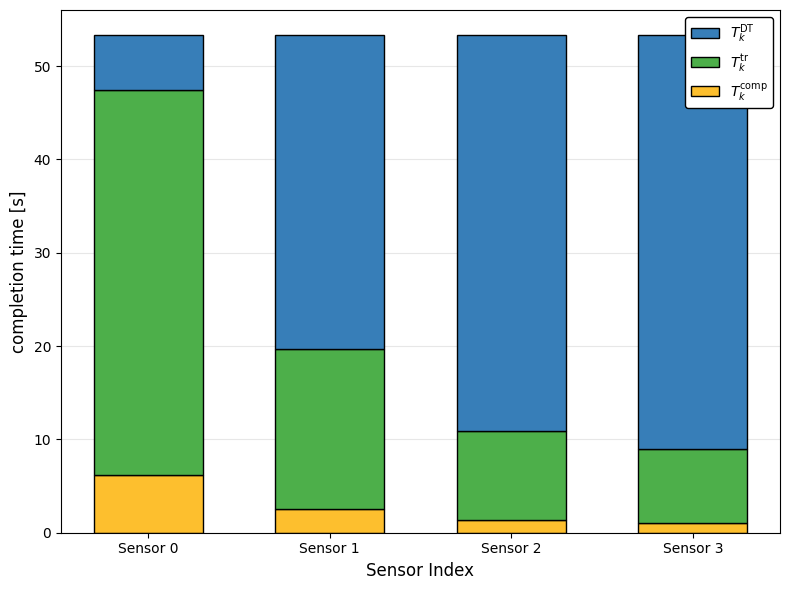

In [32]:
algo.optimize(model, max_iters=100)
    
algo.print_avg()
algo.plot()
algo.time_used

CVX

In [27]:
algo.optimize(model='new', max_iters=100)
    
algo.print_avg()
algo.plot()

start training


KeyboardInterrupt: 